In this code, we model laser noise from "Semiclassical Theory of Noise in SemiconductorLasers" by Kerry Vahala and Amnon Yariv.
The sections are as follows:
1. Define functions for generating chirp, generating reflection profile, and computing unfileterd and filtered return signals
2. Define SDE for simulating laser noise
3. Plots an example of recovering a perturbation from a noiseless baseline and noisy interrogation
4. Computes standard deviation between noisy return signals and noiseless baseline
5. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from scipy.linalg import expm
import time

# 1. Functions for generating chirp, generating reflection profile, and computing unfileterd and filtered return signals

In [2]:
def generate_chirp(t, t_pulse_end=None):
    """
    generate a chirp that lasts until t_pulse_end
    args:
        t (1d array):        times at which the chirp is evaluated
        t_pulse_end (float): time that pulse stops
    return:
        c (1d complex array): complex values of chirp at times t 
    """
    c = np.exp(2j*np.pi*(f_0*t + gamma/2*t**2)) # computes chirp at times t
    
    if t_pulse_end is not None:                  # This conditional sets the chirp to be 0 outside [0, t_pulse_end]
        c = np.where((t >= 0) & (t <= t_pulse_end), c, 0.0)
    return c

def generate_reflection_profile(t):
    """
    generate a random profile for h by randomly sampling A and theta for each time
    args:
        t (1d array): times at which the chirp is evaluated
    return:
        h (1d complex array): effects of scattering at 'positions' t
    """
    num = len(t)                                  # compute length of t
    dt = t[1] - t[0]                              # compute time step
    thetas = np.random.random(num)*2*np.pi        # take i.i.d. samples of angles uniformly on [0,2*pi]
    
    A = np.random.normal(size=num)                # take i.i.d. samples of amplitudes over a normal N(0,1) (we rescale this two lines below)
    z = t*speed_of_light_m_per_s/refractive_index # compute distance based on time, speed of light, and reflective index
    A = A*np.sqrt(np.exp(-alpha_h*z)/dt)          # multiply amplitude by np.sqrt(np.exp(-alpha*z))
                                                  # for A(t) ~ N(0,1), A(t)*k ~ N(0,k^2)
                                                  # we divide the variance by dt to treat A like a density
    return A*np.exp(1j*thetas)

def make_interp(t, values):
    """
    for a complex function f with known values f(t), define an interpolation that can be evaluated at other values of t
    args:
        t (1d array):      times on which f is defined
        values (1d array): complex values of f(t)
    return:
        f (function):      lambda function that can be evaluated at other values of t
    """
    re = interp1d(t, values.real, bounds_error=False, fill_value=0.0) # gives a function re(t) which interpolates the real part of f
    im = interp1d(t, values.imag, bounds_error=False, fill_value=0.0) # gives a function im(t) which interpolates the complex part of f
    return lambda x: re(x) + 1j*im(x)

def resample_to_common(t_native, values, t_common):
    """
    For a function f with known values on t_native, interpolate to compute values on t_common
    args:
        t_native (1d array): times on which f is originally defined
        values (1d array):   values of f(t_native)
        t_common (1d array): times to evaluate f
    return:
        f(t_common) (1d array): values of f on t_common
    """
    f = make_interp(t_native, values) # re-evaluate the function f on the desired mesh t_common
    return f(t_common)

def compute_return_signal_noisy(t, h, t_pulse_end, phi_func, t_common):
    """
    compute r(t), the return signal 
    args:
        t (1d array):         input array of times
        h (1d complex array): scattering effects
        t_pulse_end (float):  time that pulse stops
        phi_func (float):     phase noise to chirp
        t_common (1d array):  times to evaluat the return signal r
    returns:
        r_common (1d complex array):    unfiltered return r evaluated at t_common
    """
    dt = t[1] - t[0]                                                # compute the time step
    M = len(t)                                                      # count the number of times
    m_idx = np.arange(-(M-1), M)                                    # initialize an array from -(M-1) to M-1 
    arg = 2*m_idx*dt                                                # determine values to at which to evalueate chirp at
    noisy_signal = generate_chirp(arg, t_pulse_end) * phi_func(arg) # compute noisy signal
    r_full = fftconvolve(noisy_signal, h, mode='full') * dt         # compute the convolution of the noisy chirp with the reflection profile h
    t_native = 2*t[0] + 2*dt*(np.arange(len(r_full)) - (M-1))       # compute the times at which the values of r are evaluated at
    r_common = resample_to_common(t_native, r_full, t_common)       # re-evaluate the convolution r at the desired times t_common
    return r_common

def compute_filtered_signal_common(t_common, r_common, phi_func):
    """
    compute m(t), the filtered return signal 
    args:
        t_common (1d array):        times to evaluat the return signal r
        r_common (1d compex array): unfiltered return signals
        phi_func (function):        complex function for phase noise
    returns:
        m_common (1d complex array): unfiltered return r evaluated at t_common
    """
    dt_c = t_common[1] - t_common[0]                                      # compute the time step of the desired times
    n_ref = int(round(t_pulse_end/dt_c)) + 1                              # compute the number time steps between 0 and t_pulse_end
    tau_ref = np.arange(n_ref)*dt_c                                       # determine values to at which to evalueate chirp at 
    c_pure = generate_chirp(tau_ref, t_pulse_end)                         # compute pure signal that we sent out to compare against
    e_common = np.conj(phi_func(t_common)) * r_common                     # compute electrical signal at sensor
    c_conj = np.conj(c_pure[::-1])                                        # conjugate the noisy signal
    m_full = fftconvolve(e_common, c_conj, mode='full') * dt_c            # compute the convolution of the electrical signal with the conjugate of the pure chirp
    t_native = t_common[0] + (np.arange(len(m_full)) - (n_ref-1))*dt_c    # compute the times at which the values of m are evaluated at
    m_common = resample_to_common(t_native, m_full, t_common)             # re-evaluate the convolution r at the desired times t_common
    return m_common

# 2. Laser Noise

These functions describe how we model the laser noise. From "Semiclassical Theory of Noise in SemiconductorLasers: Part II" equations 14, 15, and 16 give us a linearizated SDE for noise. We can rewrite these equations as a system 

$$ 
\begin{bmatrix} \dot{\rho} \\ \dot{\phi} \\ \dot{n} \end{bmatrix}  = M \begin{bmatrix} \rho \\ \phi \\ n \end{bmatrix} + K L \begin{bmatrix} B_1 \\ B_2 \\ B_3 \end{bmatrix}
$$

where $\rho$ is the photon density, $\phi$ is the first order laser phase difference, $n$ is the carrier density, $M$ is the martrix for the deterministic dynamics, $L$ is the cholosky decomposition of the covariance matrix for the noise (i.e. $E[(Lz)^T Lz] = C$ the covariance matrix), $K$ describes how the noise feeds into each state, and $B_1$, $B_2$, and $B_3$ are independent Brownian motion processes. In vector notation, we have
$$ \vec{\dot{x}} = M \vec{x} + KL \vec{B} $$
where $\vec{x} = [\rho, \phi, n]^T$ and $\vec{B} = [B_1, B_2, B_3]^T$. The first term is deterministic and the second is stochastic. We remark that the solution to the deterministic equation is $\vec{x}(t) = \exp(M t) \, \vec{x}(0)$. In order to simulate the stochastic differential equation, we use a forward time-step method defined by
$$ \vec{x}(t + \Delta t) = \exp(M \Delta t) \, \vec{x}(t) + KL \Delta\vec{B} $$
where $\Delta \vec{B} = [b_1, b_2, b_3]^T$ with $b_i \sim N(0, \Delta t)$.

In [3]:
# Parameters for deterministic part
alpha = np.sqrt(30)                          #         linewidth enhancement factor
tau_s = 1e-9                                 # s       spontaneuous carrier decay time
gain = 5e11                                  # s^{-1}  gain rate
diff_gain = 1e-12                            # m^3/s   differential gain
p_0 = 1e20                                   # m^-3    steady-state (operating-point) photon density
mu = 3.5                                     #         refractive index of laser's semiconductor crystal
Gamma = 0.8                                  #         confinement factor
omega_m = 2.2e15                             # rad/s   lasing f?requency
omega_R = np.sqrt(Gamma*gain*diff_gain*p_0)  # rad/s   defined in pt II equation 18
tau_R = 1/((1/tau_s) + diff_gain*p_0)        # s       defined in pt II equation 17
xi_i = (mu**2)*diff_gain/omega_m             # m^{-3} susceptibility defined in pt II equation 3
xi_r = alpha*xi_i                            # m^{-3} defined in pt II equation 25

# matrix for noise from pt II equations 14, 15, and 16
M = np.array([
    [2*xi_r*omega_R**2/(omega_m*xi_i),  0,  Gamma*xi_r/(mu**2*tau_R) + omega_m*Gamma*xi_i/(2*mu**2)],
    [2*omega_R**2/omega_m,              0,  Gamma*xi_i/(mu**2*tau_R) - omega_m*Gamma*xi_r/(2*mu**2)],
    [-2*mu**2*omega_R**2/(omega_m*Gamma*xi_i), 0, -1/tau_R]
])

# Parameters for stochastic part
target_linewidth_Hz = 100                  # Hz          inverse of coherence time, larger values mean more variation in phase
Delta_omega = 2*np.pi*target_linewidth_Hz  # rad/s       angular optical linewidth (i.e. full width at half maximum or FWHM)
h_bar = 1.055e-34                          # J·s         Reduced Plank Constant
eps_0 = 8.85e-12                           # F/m         vacuum permittivity
zeta = 2.6                                 #             defined as E_{cv}/(E_{cv} - E_{vc}) in pt II in the parameters of figure 1
V_c = 3e-16                                # m^3         carrier volume
n_0 = 1e24                                 # m^{-3}      steady-state operating carrier density
A_0 = np.sqrt(2*h_bar*omega_m*p_0 / (eps_0*mu**2)) # V/m steady-state intracavity field amplitude of the noise source laser
                                                   #     the A_0 expression comes from pt II equation (4) with A_0 = |E_n|

# Covariances of the three different noise terms
W = 4*(omega_m**2)*(A_0**2)*Delta_omega/(1+alpha**2) # from pt I equations 28, 36, and 41
W1 = -A_0*(2 - 1/zeta)*(mu**2)*eps_0*W / (4*h_bar*(omega_m**2)*Gamma) # from pt II equation 50
W2 = (2 - 1/zeta)*(A_0**2)*W*(mu**4)*(eps_0) / (8*(h_bar**2)*(omega_m**4)*(Gamma**2)) + n_0/(V_c*tau_s) # from pt II equation 51

Cov = np.array([[W, 0, W1], [0, W, 0], [W1, 0, W2]])  # Define covariance matrix with basis [Delta_i, Delta_r, Delta_theta]^T
L = np.linalg.cholesky(Cov)                           # Compute L such that for independent noise z, E[(Lz)^T Lz] = Cov

def draw_noise_increment(L, dt):
    """
    compute stochastic part of the SDE for one time step
    args:
        L (2d array): cholesky factor for covariance matrix
        dt (float):   time step
    returns:
        Lz (vector):  stochastic part of SDE
    """
    z = np.random.normal(size=3)   # take 3 independent random samples of N(0,1)
    return (L @ z) * np.sqrt(dt)   # [dDelta_i, dDelta_r, dtheta] over this step, we multiply by sqrt(dt) to rescale z to N(0,dt)

# def build_step_matrices(M, dt):
#     """
#     compute deterministic part of the SDE for one time step
#     args:
#         M (2d array):  deterministic matrix from "... Laser Noise: pt II" equations 13, 14, and 15
#         dt (float):    time step
#     returns:
#         exp(M dt) (2d array): deterministic propagator over one time step
#     """
#     Phi = expm(M * dt)  # exact deterministic propagator over one step
#     return Phi

def make_phi(M, phi_domain, x0=None):
    """
    generate laser phase noise trajectory by with forward time-step method
    args:
        M (2d array):                        deterministic matrix from "... Laser Noise: pt II" equations 13, 14, and 15
        phi_domain (1d array):               array of times which we define phi on
        x0 (float vector with 3 components): initial condition for SDE           
    returns:
        phi(t) (function):                        solution to SDE
        x_final (float vector with 3 components): state at phi_domain[-1], to pass in as x0 for the next segment
    """
    if x0 is None:                                               # if no x(0) is set, initialize SDE with rho(0) = phi(0) = n(0) = 0
        x0 = np.zeros(3)
    x = np.array(x0, dtype=float)                                # set x(0) = x0                                          
    phi_trace = np.zeros(len(phi_domain))                        # initialize array phi(t)
    for k in range(1, len(phi_domain)):                          # begin forward time-step algorithm
        dt_k = phi_domain[k] - phi_domain[k-1]                        # compute time step
        Phi_k = expm(M * dt_k)                                        # recompute deterministic propagator if dt varies
        dDelta_i, dDelta_r, dtheta = draw_noise_increment(L, dt_k)    # compute stoachstic part
        v = np.array([                                                # compute the vector v = KL delta B
        dDelta_i/(2*omega_m*A_0) - (Gamma*xi_r/mu**2)*dtheta,
        -dDelta_r/(2*omega_m*A_0) - (Gamma*xi_i/mu**2)*dtheta,
        dtheta
        ])
        x = Phi_k @ x + v                                             # compute the vector x(t + delta t)
        phi_trace[k] = x[1]                                           # set phi(t+delta t) equal to the second component of the vector x

    phi_interp = interp1d(phi_domain, phi_trace, bounds_error=False, fill_value=0.0)  # create an interpolation function of the white noise so it can be evaluated at other times
    phi_trace = lambda t: np.exp(1j * (phi_interp(t)))                # create the complex perturbation from the noisy phase
    return phi_trace, x.copy()

# 3. Compute reconstruction of environmental signal from a noisy interrogation signal

The function $g(t)$ describes the environmental perturbation on the cable. The default is a sinosoidal perturbation. However, if you want to test the effect of noise on the baseline, you can use $g(t) = 0$. To compute the reconstruction, we look at two fiber realizations $h_x(t)$ and $h_y(t)$ and compute the filtered return for each.

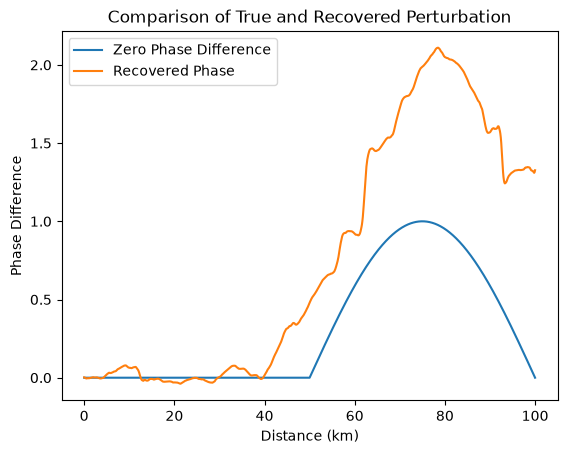

In [4]:
np.random.seed(0)   # set seed for random events

# define fiber parameters
fiber_length_km = 100.0                # fiber length in km
refractive_index = 1.468               # refractive index of light in fiber
speed_of_light_m_per_s = 299_792_458.0 # speed of light in a vacuum
f_0 = 0                                # base frequency
gamma = 5e6                            # frequency gradient
alpha_h = 3.5e-6                         # decay rate of laser strength with distance ( i.e. h(t) = A(t)e^{i theta(t)} where A(t) ~ N(0, exp(-tz)) )

T_oneway = fiber_length_km*1000*refractive_index/speed_of_light_m_per_s    # time in seconds for light to travel from sensor to end of cable
num_times = 1001                                          # number of times in discritization
times = np.linspace(0, 2*T_oneway, num_times)             # array of times for light to travel to the end of the cable and back
dt = times[1]-times[0]                                    # fixed time step
t_common = times                                          # times to evaluate return signal and filtered return signal
t_pulse_end = T_oneway*0.1                                # define time at which interrogation signal stops

pert_freq = 2*np.pi/T_oneway
def g(t):
    """
    define a spatial environmental perturbation on cable where t is light-seconds (for the speed of light in the cable)
    setting g(t) = 0 means there is no environemental perturbation so any differences in return signal are due to noise
    args:
        t (1d array): times to define perturbation on
    returns:
        g(t) (1d array): phase perturbation to cable profile h
    """
    y = -np.sin(pert_freq*t)*np.heaviside(T_oneway - t, 0)*np.heaviside(t - T_oneway/2, 0)
    # y = np.zeros(len(t))                                  # if you want to test the effects of noise on the baseline un-comment this line
    return y

g_true = g(times/2) # compute the true g that we will try to reconstruct

phi_domain = np.linspace(0, 2*T_oneway, 4*len(times)) # set domain for noise (after the chirp c(t) = 0, so the noise has no effect)

phi_func1 = lambda t: 1                               # define laser noise for baseline (lambda t: 1 is no noise)
# phi_func1, _ = make_phi(M, phi_domain)              # if you want a noisy baseline, un-comment this line

phi_func2, _ = make_phi(M, phi_domain)                # define laser noise for x and y component

# Compute two independent cable profiles for the two polarizations of light
h_x = generate_reflection_profile(times)
h_y = generate_reflection_profile(times)
h_x_pert = h_x * np.exp(1j*g(times))
h_y_pert = h_y * np.exp(1j*g(times))

# Compute the unfiltered return signal for the baseline and for the perturbation by g(t)
r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
r_pert_x  = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
r_pert_y  = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)

# Compute the filtered return signal for the baseline and for the perturbation by g(t)
m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
m_pert_x  = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)
m_pert_y  = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)

# Compute the phase difference between the baseline and the recovery using both polarizations of light
s_combined = m_pert_x*np.conj(m_base_x) + m_pert_y*np.conj(m_base_y)
g_estimate = np.angle(s_combined)

# Convert times array to distance
distance_km = (t_common/2) * speed_of_light_m_per_s / refractive_index / 1000

# Plot phase difference between pure and noisy filtered return
plt.plot(distance_km, g_true, label='Zero Phase Difference')
plt.plot(distance_km, g_estimate, label='Recovered Phase')
plt.title("Comparison of True and Recovered Perturbation")
plt.ylabel("Phase Difference")
plt.xlabel("Distance (km)")
plt.legend()
plt.show()

# 4. Compute the reconstruction of an environmental disturbance from the same repeated interrogation signal

A single noisy reconstruction may differ from the true environemental perturbation. However, if we send multiple chirps, we may be able to average the reconstructions to get a better approximation. We can only send one signal into the fiber at a time, so we assume that the time between interrogation signals is long enough for the previous signal to have traveled the entire length of the cable and back. Furthermore, an actual environmetnal disturbance may change over time, but we will assume that the cable is short enough (i.e. a single pulse return trip is short enough) that the environemental disturbance $g(t)$ is unchanging.

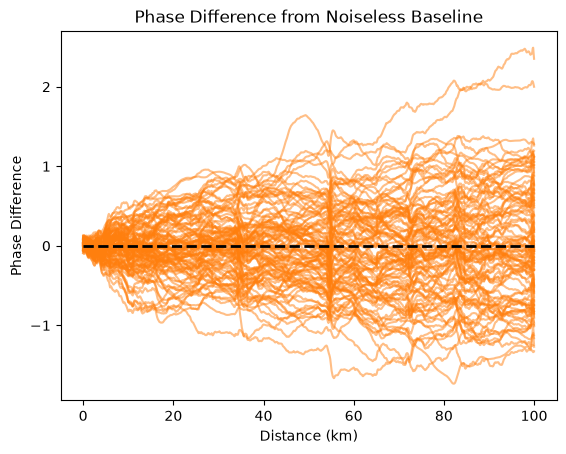

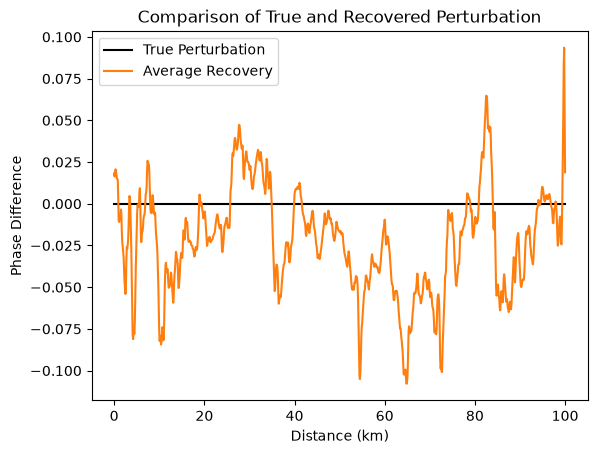

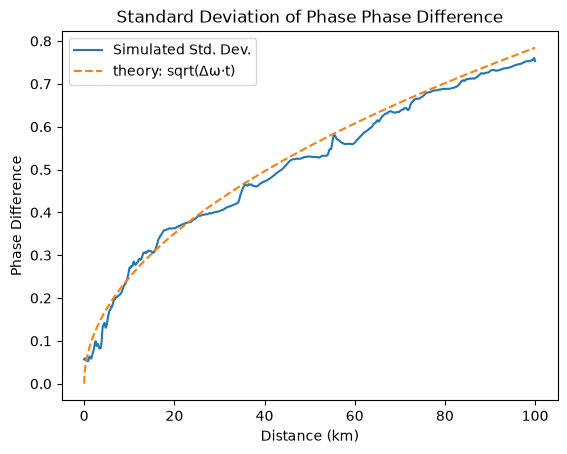

In [15]:
np.random.seed(0) # set seed for random events

# define fiber parameters
fiber_length_km = 100.0                # fiber length in km
refractive_index = 1.468               # refractive index of light in fiber
speed_of_light_m_per_s = 299_792_458.0 # speed of light in a vacuum
f_0 = 0                                # base frequency
gamma = 5e6                            # frequency gradient
alpha_h = 3.5e-6                       # decay rate of laser strength with distance ( i.e. h(t) = A(t)e^{i theta(t)} where A(t) ~ N(0, exp(-tz)) )

T_oneway = fiber_length_km*1000*refractive_index/speed_of_light_m_per_s    # time in seconds for light to travel from sensor to end of cable
num_times = 1001                                          # number of times in discritization
times = np.linspace(0, 2*T_oneway, num_times)             # array of times for light to travel to the end of the cable and back
dt = times[1]-times[0]                                    # fixed time step
t_common = times                                          # times to evaluate return signal and filtered return signal
t_pulse_end = T_oneway*0.1                                # define time at which interrogation signal stops
              
init_noise = np.zeros(3)                                  # Initial state for SDE               

pert_freq = 3*np.pi/T_oneway
def g(t):
    """
    define a spatial environmental perturbation on cable where t is light-seconds (for the speed of light in the cable)
    setting g(t) = 0 means there is no environemental perturbation so any differences in return signal are due to noise
    args:
        t (1d array): times to define perturbation on
    returns:
        g(t) (1d array): phase perturbation to cable profile h
    """
    # y = -np.sin(pert_freq*t)*np.heaviside(T_oneway - t, 0)*np.heaviside(t - T_oneway/2, 0)
    y = np.zeros(len(t))                                  # this line is for testing the baseline
    return y

h_x = generate_reflection_profile(times) # generate cable profile for x component
h_y = generate_reflection_profile(times) # generate cable profile for y component
h_x_pert = h_x * np.exp(1j*g(times))     # apply environmental disturbance to the x cable profile
h_y_pert = h_y * np.exp(1j*g(times))     # apply environmental disturbance to the y cable profile

g_true = g(times/2)  # compute the true g that we will try to reconstruct
combined_data = []   # initialize list for storing computed value of e^{i g(t/2)} from x and y components
estimates = []       # initialize list for storing reconstructions of g(t/2)
errors = []

phi_func1 = lambda t: 1   # define laser noise for baseline (lambda t: 1 is no noise)

# Compute a single baseline to use for all trials
r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)

# print(init_noise)

distance_km = (t_common/2) * speed_of_light_m_per_s / refractive_index / 1000

num_trials = 100 # define number of interrogation signals to send
for i in range(num_trials):
    np.random.seed(i) # change randomness between trials
    
    phi_domain = np.linspace(0, 2*T_oneway, 4*len(times)) # set domain for noise (after the chirp c(t) = 0, so the noise has no effect)
    
    phi_func2, init_noise = make_phi(M, phi_domain, init_noise) # define laser noise for x and y component
                                                                # carry over final state of laser noise from previous pulse
    
    r_pert_x  = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
    r_pert_y  = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)
    
    m_pert_x  = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
    m_pert_y  = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)
    
    s_combined = m_pert_x*np.conj(m_base_x) + m_pert_y*np.conj(m_base_y)
    g_estimate = np.angle(s_combined)
    estimates.append(g_estimate)
    errors.append(g_estimate - g_true)

    combined_data.append(s_combined)
    
    # Plot noisy return
    plt.plot(distance_km, g_estimate, color = 'tab:orange', alpha = 0.5)
    
# Plot baseline in black
plt.plot(distance_km, g_true, label='Zero Phase', linestyle = '--', linewidth=2.0, color = 'black')
plt.title("Phase Difference from Noiseless Baseline")
plt.ylabel("Phase Difference")
plt.xlabel("Distance (km)")
# plt.legend()
plt.show()

# Compute average of noisy reconstructions (take care of phase wrapping by computing average in complex plane then computing phase)
combined_data = np.array(combined_data)        # recast list to numpy array
mean_complex = np.mean(combined_data, axis=0)  # compute average of s_combined for each time t
g_estimate_circmean = np.angle(mean_complex)   # compute the phase of the average for each time t

# Plot average of reconstructions
plt.plot(distance_km, g_true, label='True Perturbation', color = 'black')
plt.plot(distance_km, g_estimate_circmean, label = 'Average Recovery', color = 'tab:orange')
plt.title("Comparison of True and Recovered Perturbation")
plt.ylabel("Phase Difference")
plt.xlabel("Distance (km)")
plt.legend()
plt.show()

# Plot Standard Deviation as a function of distance along with theoretical curve
errors = np.array(errors)

plt.plot(distance_km, np.sqrt(np.mean(errors**2, axis = 0)), label = 'Simulated Std. Dev.')
plt.plot(distance_km, np.sqrt(Delta_omega*times), linestyle = '--', label='theory: sqrt(Δω·t)')
plt.title("Standard Deviation of Phase Phase Difference")
plt.ylabel("Phase Difference")
plt.xlabel("Distance (km)")
plt.legend()
plt.show()

# 5. Look at phase difference between baseline and average of N noisy returns.

For each N in N_vals compute the average of N noisy trials and compare the phase of the filtered return to the phase of the baseline. We see that with larger N values, the average converges to zero phase difference. In particular, averaging over many trials with with a constant environmental state will recover a return signal that is approximately equal to the baseline return signal for a pure chirp.

computing N = 5
computing N = 20
computing N = 100


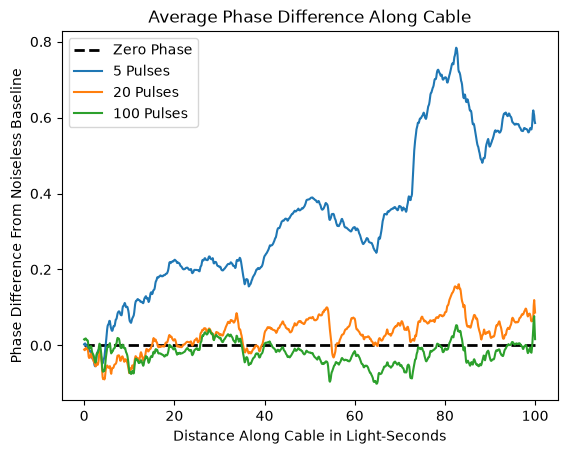

In [6]:
np.random.seed(0)    # set seed for random events

# define fiber parameters
fiber_length_km = 100.0                # fiber length in km
refractive_index = 1.468               # refractive index of light in fiber
speed_of_light_m_per_s = 299_792_458.0 # speed of light in a vacuum
f_0 = 0                                # base frequency
gamma = 5e6                            # frequency gradient
alpha_h = 3.5e-6                       # decay rate of laser strength with distance ( i.e. h(t) = A(t)e^{i theta(t)} where A(t) ~ N(0, exp(-tz)) )

T_oneway = fiber_length_km*1000*refractive_index/speed_of_light_m_per_s    # time in seconds for light to travel from sensor to end of cable
num_times = 1001                                          # number of times in discritization
times = np.linspace(0, 2*T_oneway, num_times)             # array of times for light to travel to the end of the cable and back
dt = times[1]-times[0]                                    # fixed time step
t_common = times                                          # times to evaluate return signal and filtered return signal
t_pulse_end = T_oneway*0.1                                # define time at which interrogation signal stops

init_noise = np.zeros(3)                                  # Initial state for SDE    

pert_freq = 3*np.pi/T_oneway
def g(t):
    """
    define a spatial environmental perturbation on cable where t is light-seconds (for the speed of light in the cable)
    setting g(t) = 0 means there is no environemental perturbation so any differences in return signal are due to noise
    args:
        t (1d array): times to define perturbation on
    returns:
        g(t) (1d array): phase perturbation to cable profile h
    """
    # y = -np.sin(pert_freq*t)*np.heaviside(T_oneway - t, 0)*np.heaviside(t - T_oneway/2, 0)
    y = np.zeros(len(t))                                  # this line is for testing the baseline
    return y

h_x = generate_reflection_profile(times) # generate cable profile for x component
h_y = generate_reflection_profile(times) # generate cable profile for y component
h_x_pert = h_x * np.exp(1j*g(times))     # apply environmental disturbance to the x cable profile
h_y_pert = h_y * np.exp(1j*g(times))     # apply environmental disturbance to the y cable profile

g_true = g(times/2)  # compute the true g that we will try to reconstruct

phi_func1 = lambda t: 1   # define laser noise for baseline (lambda t: 1 is no noise)

# Compute a single baseline to use for all trials
r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)

N_vals = np.array([5, 20, 100]) # define vector of number of trials to avarage over

# Convert times array to distance
distance_km = (t_common/2) * speed_of_light_m_per_s / refractive_index / 1000

# Plot a zero phase difference line for reference
plt.plot(distance_km, g_true, label='Zero Phase', linestyle = '--', linewidth=2.0, color = 'black')

# For each N value in N_vals, compute the average of N noisy return signals
for index, num_trials in enumerate(N_vals):
    print(f"computing N = {num_trials}")
    combined_data = []   # initialize list for storing computed value of e^{i g(t/2)} from x and y components
    x_data = []          # initialize list for storing returned signals from x profile
    y_data = []          # initialize list for storing returned signals from y profile
    estimates = []       # initialize list for storing reconstructions of g(t/2)

    # Compute N filtereed return signals
    for i in range(num_trials):
        np.random.seed(i)
        
        phi_domain = np.linspace(0, 2*T_oneway, 4*len(times)) # set domain for noise (after the chirp c(t) = 0, so the noise has no effect)
        
        phi_func2, init_noise = make_phi(M, phi_domain, init_noise)  # define laser noise for x and y component
                                                                    # carry over final state of laser noise from previous pulse

        # Compute unfiltered return signals from noisy interrogations
        r_pert_x  = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
        r_pert_y  = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)

        # Compute filtered return signals from noisy interrogations
        m_pert_x  = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
        m_pert_y  = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)

        # Store x and y filtered return signals
        x_data.append(m_pert_x)
        y_data.append(m_pert_y)

    # Compute average x and y filtered return as a complex function of cable distance
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    x_mean_data = np.mean(x_data, axis = 0)
    y_mean_data = np.mean(y_data, axis = 0)

    # Compute phase difference between average filtered return and noiseless baseline
    avg_data = np.angle(x_mean_data*np.conj(m_base_x) + y_mean_data*np.conj(m_base_y))
    
    # Plot average of reconstructions
    plt.plot(distance_km, avg_data, label = f"{num_trials} Pulses")
    
plt.title("Average Phase Difference Along Cable")
plt.ylabel("Phase Difference From Noiseless Baseline")
plt.xlabel("Distance Along Cable in Light-Seconds")
plt.legend()
plt.show()

# 6. Compute decrease in average variance as number of trials increases

The vector N_vals determines the number of trials N to test. For each N we take the average standard deviation at the far end of the cable over n_repeats trials.

  done in 105.02 s


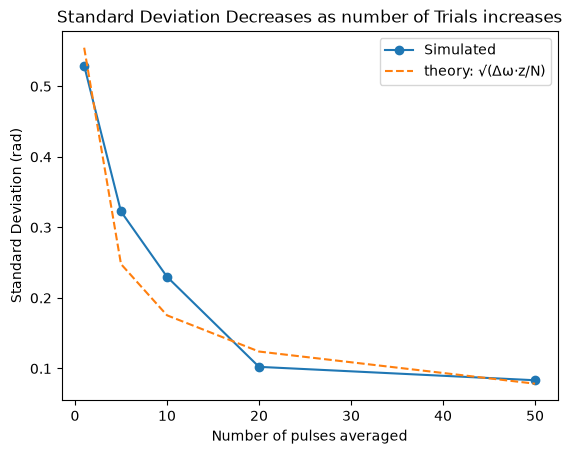

In [14]:
np.random.seed(0) # set seed for random events

pert_freq = 3*np.pi/T_oneway
def g(t):
    """
    define a spatial environmental perturbation on cable where t is light-seconds (for the speed of light in the cable)
    setting g(t) = 0 means there is no environemental perturbation so any differences in return signal are due to noise
    args:
        t (1d array): times to define perturbation on
    returns:
        g(t) (1d array): phase perturbation to cable profile h
    """
    # y = -np.sin(pert_freq*t)*np.heaviside(T_oneway - t, 0)*np.heaviside(t - T_oneway/2, 0)
    y = np.zeros(len(t))                                  # this line is for testing the baseline
    return y

h_x = generate_reflection_profile(times) # generate cable profile for x component
h_y = generate_reflection_profile(times) # generate cable profile for y component
h_x_pert = h_x * np.exp(1j*g(times))     # apply environmental disturbance to the x cable profile
h_y_pert = h_y * np.exp(1j*g(times))     # apply environmental disturbance to the y cable profile

phi_func1 = lambda t: 1   # define laser noise for baseline (lambda t: 1 is no noise)

# Compute a single baseline to use for all trials
r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)

def sweep_num_trials(N_vals, target_linewidth_Hz, t_index=-1, n_repeats=5):
    """
    t_index=-1 tests the far end (worst case); pick a smaller index to test a nearer point
    args:
        N_vals: list for number of trials
        target_linewidth_Hz
        t_index: where to test
        n_repeates: number of times to run each experiment
    returns:
        average RMSE for each N value
    
    """
    # ... build W, W1, W2, Cov, L, M as before for this target_linewidth_Hz ...
    errors_by_N = []
    for N in N_vals:
        rep_errors = []
        for rep in range(n_repeats):
            x_returns = []        # initialize list for storing returned signals from x profile
            y_returns = []        # initialize list for storing returned signals from y profile
            phi_init = [0, 0, 0]
            for i in range(N):
                np.random.seed(rep*10000 + i)   # distinct draws per repeat
                phi_domain = np.linspace(0, 2*T_oneway, 4*len(times))
                phi_func2, phi_init = make_phi(M, phi_domain, phi_init)
                r_pert_x = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
                r_pert_y = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)
                m_pert_x = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
                m_pert_y = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)
                # combined.append(m_pert_x*np.conj(m_base_x) + m_pert_y*np.conj(m_base_y))
                x_returns.append(m_pert_x)
                y_returns.append(m_pert_y)
            x_mean = np.mean(np.array(x_returns), axis=0)
            y_mean = np.mean(np.array(y_returns), axis=0)
            # mean_complex = np.mean(combined, axis=0)
            mean_complex = x_mean*np.conj(m_base_x) + y_mean*np.conj(m_base_y)
            g_circmean = np.angle(mean_complex)
            rep_errors.append((g_circmean - g_true)[t_index])
        errors_by_N.append(np.sqrt(np.mean(np.array(rep_errors)**2)))
    return np.array(errors_by_N)

time_start = time.time()

N_vals = np.array([1, 5, 10, 20, 50])
rmse_by_N = sweep_num_trials(N_vals, target_linewidth_Hz=100)

time_end = time.time()
print(f"  done in {time_end-time_start:.2f} s")

plt.plot(N_vals, rmse_by_N, 'o-', label='Simulated')
plt.plot(N_vals, np.sqrt(2*np.pi*target_linewidth_Hz*T_oneway/N_vals), '--', label='theory: √(Δω·t/N)')
# plt.xscale('log'); plt.yscale('log')
plt.title("Standard Deviation Decreases as number of Trials increases")
plt.xlabel('Number of pulses averaged'); plt.ylabel('Standard Deviation (rad)')
plt.legend()
plt.show()

# 7. Reconstruct environmental perturbation from noisy baseline

First we compute the noiseless recovery for comparison. Then average the filtered return of baseline_trials number of noisy trials to construct the baseline. After applying the fixed environemental perturbation g(t), we average over num_trials number of noisy trials to get the perturbed filtered return. The phase difference between the averaged noisy perturbed signal and averaged noisy baseline gives us the environmental recovery in green.

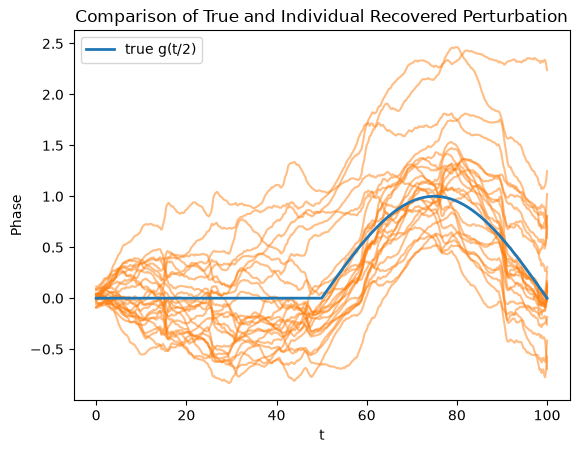

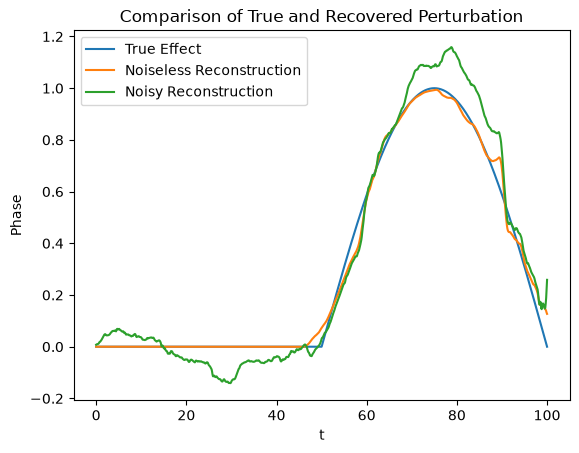

In [13]:
np.random.seed(1)  # set seed for random events

# define fiber parameters
fiber_length_km = 100.0                # fiber length in km
refractive_index = 1.468               # refractive index of light in fiber
speed_of_light_m_per_s = 299_792_458.0 # speed of light in a vacuum
f_0 = 0                                # base frequency
gamma = 5e6                            # frequency gradient
alpha_h = 3.5e-6                       # decay rate of laser strength with distance ( i.e. h(t) = A(t)e^{i theta(t)} where A(t) ~ N(0, exp(-tz)) )

T_oneway = fiber_length_km*1000*refractive_index/speed_of_light_m_per_s    # time in seconds for light to travel from sensor to end of cable
num_times = 1001                                          # number of times in discritization
times = np.linspace(0, 2*T_oneway, num_times)             # array of times for light to travel to the end of the cable and back
dt = times[1]-times[0]                                    # fixed time step
t_common = times                                          # times to evaluate return signal and filtered return signal
t_pulse_end = T_oneway*0.1                                # define time at which interrogation signal stops

pulse_delay = T_oneway*0.1                     
extra_domain = np.arange(0, pulse_delay, dt)
init_noise = np.zeros(3)

# Convert times array to distance
distance_km = (t_common/2) * speed_of_light_m_per_s / refractive_index / 1000

pert_freq = 2*np.pi/T_oneway
def g(t):
    """
    define a spatial environmental perturbation on cable where t is light-seconds (for the speed of light in the cable)
    setting g(t) = 0 means there is no environemental perturbation so any differences in return signal are due to noise
    args:
        t (1d array): times to define perturbation on
    returns:
        g(t) (1d array): phase perturbation to cable profile h
    """
    y = -np.sin(pert_freq*t)*np.heaviside(T_oneway - t, 0)*np.heaviside(t - T_oneway/2, 0)
    # y = np.zeros(len(t))                                  # this line is for testing the baseline
    return y

# Generate a single reflection profile to use for all interrogation signals
h_x = generate_reflection_profile(times) # generate cable profile for x component
h_y = generate_reflection_profile(times) # generate cable profile for y component
h_x_pert = h_x * np.exp(1j*g(times))     # apply environmental disturbance to the x cable profile
h_y_pert = h_y * np.exp(1j*g(times))     # apply environmental disturbance to the y cable profile

# Generate noiseless recovery
phi_func1 = lambda t: 1              # define laser noise for baseline (lambda t: 1 is no noise)
phi_func2 = lambda t: 1              # define laser noise for baseline (lambda t: 1 is no noise)

r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
r_pert_x  = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
r_pert_y  = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)

m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
m_pert_x  = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)
m_pert_y  = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)

s_combined = m_pert_x*np.conj(m_base_x) + m_pert_y*np.conj(m_base_y)
g_noiseless = np.angle(s_combined)

g_true = g(times/2)  # compute the true g that we will try to reconstruct
combined_data = []   # initialize list for storing computed value of e^{i g(t/2)} from x and y components
base_x_returns = []  # initialize list for storing returned signals from x profile
base_y_returns = []  # initialize list for storing returned signals from y profile

# compute a baseline from {baseline_trials} noisy interrogations
baseline_trials = 25
for i in range(baseline_trials):
    phi_domain = np.linspace(0, 2*T_oneway, 4*len(times)) # set domain for noise (after the chirp c(t) = 0, so the noise has no effect)
        
    # phi_func1 = lambda t: 1   # define laser noise for baseline (lambda t: 1 is no noise)
    phi_func1, init_noise = make_phi(M, phi_domain, init_noise)          # define laser noise for x and y component for baseline interrogations
    
    # Compute a single noisy baseline return signal
    r_base_x = compute_return_signal_noisy(times, h_x, t_pulse_end, phi_func1, t_common)
    r_base_y = compute_return_signal_noisy(times, h_y, t_pulse_end, phi_func1, t_common)
    m_base_x = compute_filtered_signal_common(t_common, r_base_x, phi_func1)
    m_base_y = compute_filtered_signal_common(t_common, r_base_y, phi_func1)

    # Store base x and y baseline filtered return signals
    base_x_returns.append(m_base_x)
    base_y_returns.append(m_base_y)

# Compute average of noisy trials to make baseline
m_base_x = np.mean(np.array(base_x_returns), axis=0)
m_base_y = np.mean(np.array(base_y_returns), axis=0)

x_data = []          # initialize list for storing returned signals from x profile
y_data = []          # initialize list for storing returned signals from y profile
estimates = []       # initialize list for storing reconstructions of g(t/2)

# Compute a recovery from {num_trials} noisy interrogations
num_trials = 25 # define number of interrogation signals to send
for i in range(num_trials):
    phi_domain = np.linspace(0, 2*T_oneway, 4*len(times)) # set domain for noise (after the chirp c(t) = 0, so the noise has no effect)
    
    phi_func2, init_noise = make_phi(M, phi_domain, init_noise)          # define laser noise for x and y component of perturbed interrogations

    # Compute a single perturbed return signal
    r_pert_x  = compute_return_signal_noisy(times, h_x_pert, t_pulse_end, phi_func2, t_common)
    r_pert_y  = compute_return_signal_noisy(times, h_y_pert, t_pulse_end, phi_func2, t_common)
    m_pert_x  = compute_filtered_signal_common(t_common, r_pert_x, phi_func2)
    m_pert_y  = compute_filtered_signal_common(t_common, r_pert_y, phi_func2)

    # Store base x and y perturbed return signals
    x_data.append(m_pert_x)
    y_data.append(m_pert_y)
    
    s_combined = m_pert_x*np.conj(m_base_x) + m_pert_y*np.conj(m_base_y)
    g_estimate = np.angle(s_combined)
    estimates.append(g_estimate)

    combined_data.append(s_combined)

    # plot each individual perturbed return signal
    plt.plot(distance_km, g_estimate, color = 'tab:orange', alpha = 0.5)

# Compute average of noisy trials to get perturbed return
x_data = np.array(x_data)
y_data = np.array(y_data)
x_mean_data = np.mean(x_data, axis = 0)
y_mean_data = np.mean(y_data, axis = 0)
avg_data = np.angle(x_mean_data*np.conj(m_base_x) + y_mean_data*np.conj(m_base_y))
    
# Plot baseline in blue
plt.plot(distance_km, g_true, label='true g(t/2)', linewidth=2.0, color = 'tab:blue')
plt.title("Comparison of True and Individual Recovered Perturbation")
plt.ylabel("Phase")
plt.xlabel("t")
plt.legend()
plt.show()

# Compute average of noisy reconstructions (take care of phase wrapping by computing average in complex plane then computing phase)
combined_data = np.array(combined_data)        # recast list to numpy array
mean_complex = np.mean(combined_data, axis=0)  # compute average of s_combined for each time t
g_estimate_circmean = np.angle(mean_complex)   # compute the phase of the average for each time t

# Plot average of reconstructions
plt.plot(distance_km, g_true, label='True Effect')
plt.plot(distance_km, g_noiseless, label = 'Noiseless Reconstruction')
plt.plot(distance_km, g_estimate_circmean, label = 'Noisy Reconstruction')
plt.title("Comparison of True and Recovered Perturbation")
plt.ylabel("Phase")
plt.xlabel("t")
plt.legend()
plt.show()